# 🧪 PyTorch Lab 3.1: Variational Autoencoders (VAE)

This notebook introduces Variational Autoencoders with PyTorch. It combines theory, implementation, visualization, and interpretation exercises.

The goal is not only to train a model, but also to understand what the latent space represents and how the probabilistic formulation differs from a standard autoencoder.


## 1. Variational Autoencoders - Theory Recall

### 1.1 From Autoencoders to Generative Models

A standard autoencoder learns a deterministic mapping:

$$
x \rightarrow z \rightarrow \hat{x}
$$

where:
- the encoder maps the input to a latent representation: $z = f_\phi(x)$
- the decoder reconstructs the input: $\hat{x} = g_\theta(z)$

The training objective is usually a reconstruction loss:

$$
\mathcal{L}_{AE}(x) = \|x - \hat{x}\|^2
$$

This works well for compression and denoising, but it is not directly a generative model. In particular, a standard autoencoder does not tell us how to sample a meaningful latent vector $z$.

### 1.2 Latent Variable Modeling

A VAE assumes that each observation $x$ is generated from an unobserved latent variable $z$:

$$
p_\theta(x) = \int p_\theta(x \mid z) p(z) \, dz
$$

where:
- $p(z)$ is a prior distribution, usually $\mathcal{N}(0, I)$
- $p_\theta(x \mid z)$ is the decoder, also called the likelihood

Once the model is trained, we can generate new samples by:
1. sampling $z \sim p(z)$
2. decoding $z$ into an image using $p_\theta(x \mid z)$

The difficulty is that the marginal likelihood $p_\theta(x)$ is usually intractable.

### 1.3 Variational Inference

The true posterior $p_\theta(z \mid x)$ is also intractable. We approximate it with a distribution predicted by the encoder:

$$
q_\phi(z \mid x)
$$

This approximate posterior is learned jointly with the decoder.

The VAE maximizes the Evidence Lower Bound, called the ELBO:

$$
\log p_\theta(x) \geq \mathcal{L}(x)
$$

with:

$$
\mathcal{L}(x)
=
\mathbb{E}_{q_\phi(z \mid x)}
\left[
\log p_\theta(x \mid z)
\right]
-
\mathrm{KL}
\left(
q_\phi(z \mid x) \| p(z)
\right)
$$

The first term encourages good reconstructions. The second term regularizes the latent space so that it stays close to the prior distribution.

### 1.4 Gaussian Encoder

In this notebook, the encoder outputs a diagonal Gaussian distribution:

$$
q_\phi(z \mid x)
=
\mathcal{N}
\left(
\mu_\phi(x),
\mathrm{diag}(\sigma^2_\phi(x))
\right)
$$

The neural network predicts:
- the mean vector $\mu_\phi(x)$
- the log-variance vector $\log \sigma^2_\phi(x)$

We predict the log-variance instead of the variance because it is numerically more stable and can take any real value.

### 1.5 Reparameterization Trick

To train the encoder with backpropagation, the sampling step must be differentiable. We therefore write:

$$
z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon,
\quad
\epsilon \sim \mathcal{N}(0, I)
$$

The randomness is isolated in $\epsilon$, while $\mu_\phi(x)$ and $\sigma_\phi(x)$ remain differentiable.

### 1.6 What Should Students Observe?

During this lab, pay attention to three questions:
- Are reconstructions sharp or blurry?
- Is the latent space continuous?
- Do digits form separated clusters even though labels are not used during training?

A VAE is not trained as a classifier. Therefore, perfect class separation is not expected. The latent space should instead be smooth, structured, and useful for generation.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np


In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of test images: {len(test_dataset)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 13.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 353kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 32.5MB/s]

Number of training images: 60000
Number of test images: 10000


In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


In [4]:
def loss_function(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction term.
    # Binary cross entropy is common for MNIST because pixels are in [0, 1].
    bce = nn.functional.binary_cross_entropy(
        recon_x,
        x,
        reduction="sum"
    )

    # KL divergence between q_phi(z|x) and N(0, I).
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = bce + beta * kl

    return total_loss, bce, kl


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LATENT_DIM = 2
BETA = 1.0
EPOCHS = 30

model = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = {
    "loss": [],
    "reconstruction": [],
    "kl": []
}

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0
    total_bce = 0
    total_kl = 0

    for data, _ in train_loader:
        data = data.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(data)
        loss, bce, kl = loss_function(recon, data, mu, logvar, beta=BETA)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kl += kl.item()

    n = len(train_loader.dataset)

    history["loss"].append(total_loss / n)
    history["reconstruction"].append(total_bce / n)
    history["kl"].append(total_kl / n)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"loss: {total_loss / n:.2f} | "
        f"reconstruction: {total_bce / n:.2f} | "
        f"KL: {total_kl / n:.2f}"
    )


Epoch 01/30 | loss: 192.08 | reconstruction: 186.43 | KL: 5.66
Epoch 02/30 | loss: 168.24 | reconstruction: 163.03 | KL: 5.21
Epoch 03/30 | loss: 164.25 | reconstruction: 158.94 | KL: 5.31
Epoch 04/30 | loss: 161.93 | reconstruction: 156.51 | KL: 5.41
Epoch 05/30 | loss: 160.18 | reconstruction: 154.67 | KL: 5.51
Epoch 06/30 | loss: 158.66 | reconstruction: 153.09 | KL: 5.58
Epoch 07/30 | loss: 157.40 | reconstruction: 151.72 | KL: 5.67
Epoch 08/30 | loss: 156.38 | reconstruction: 150.64 | KL: 5.74
Epoch 09/30 | loss: 155.51 | reconstruction: 149.72 | KL: 5.79
Epoch 10/30 | loss: 154.70 | reconstruction: 148.87 | KL: 5.83
Epoch 11/30 | loss: 154.07 | reconstruction: 148.18 | KL: 5.88
Epoch 12/30 | loss: 153.50 | reconstruction: 147.59 | KL: 5.92
Epoch 13/30 | loss: 152.93 | reconstruction: 147.01 | KL: 5.93
Epoch 14/30 | loss: 152.44 | reconstruction: 146.47 | KL: 5.98
Epoch 15/30 | loss: 152.01 | reconstruction: 146.02 | KL: 5.99
Epoch 16/30 | loss: 151.59 | reconstruction: 145.57 | K

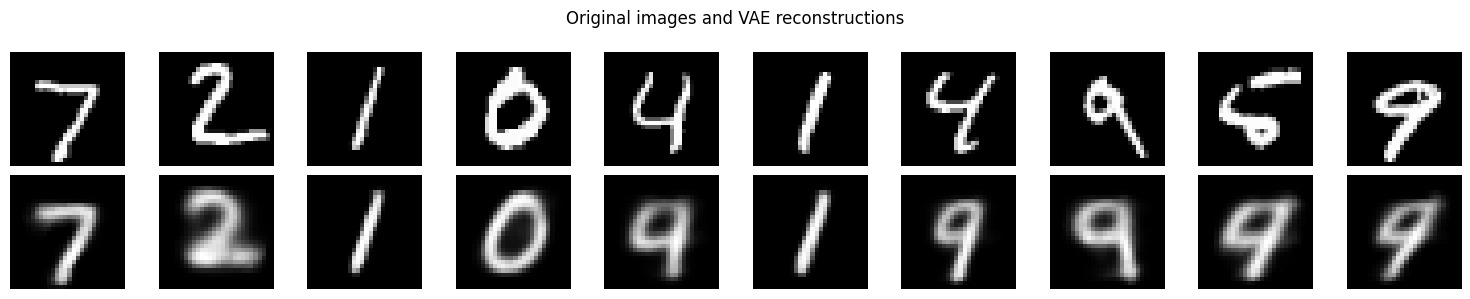

In [6]:
def show_reconstructions(model, data_loader, n_images=10):
    model.eval()

    with torch.no_grad():
        data, _ = next(iter(data_loader))
        data = data[:n_images].to(device)

        recon, _, _ = model(data)

        fig, axes = plt.subplots(2, n_images, figsize=(1.5 * n_images, 3))

        for i in range(n_images):
            axes[0, i].imshow(data[i].cpu().squeeze(), cmap="gray")
            axes[0, i].axis("off")

            axes[1, i].imshow(recon[i].cpu().squeeze(), cmap="gray")
            axes[1, i].axis("off")

        axes[0, 0].set_ylabel("Original", fontsize=12)
        axes[1, 0].set_ylabel("Reconstruction", fontsize=12)

        plt.suptitle("Original images and VAE reconstructions")
        plt.tight_layout()
        plt.show()

show_reconstructions(model, test_loader)


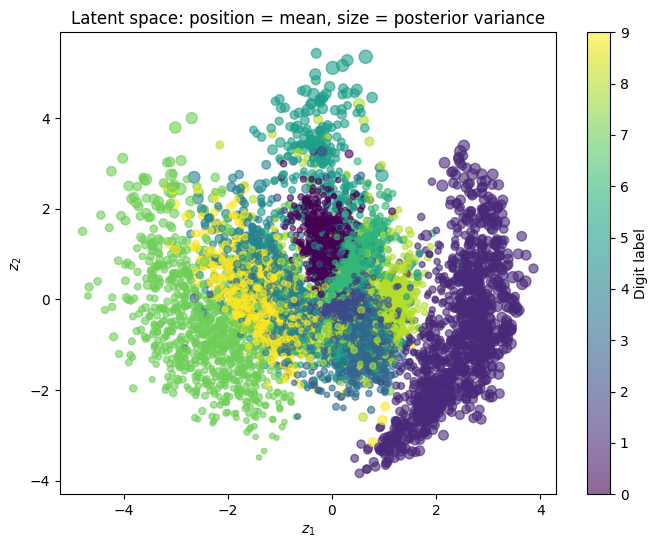

In [7]:
def collect_latent_statistics(model, data_loader):
    model.eval()

    latents = []
    variances = []
    labels = []

    with torch.no_grad():
        for data, y in data_loader:
            data = data.to(device)

            mu, logvar = model.encode(data)
            var = torch.exp(logvar)

            latents.append(mu.cpu())
            variances.append(var.cpu())
            labels.append(y)

    latents = torch.cat(latents, dim=0)
    variances = torch.cat(variances, dim=0)
    labels = torch.cat(labels, dim=0)

    return latents, variances, labels


latents, variances, labels = collect_latent_statistics(model, test_loader)

if latents.shape[1] != 2:
    print("The latent dimension is not 2. The plot uses only the first two dimensions.")

z = latents[:, :2]
var_scalar = variances.mean(dim=1)

sizes = (var_scalar - var_scalar.min()) / (var_scalar.max() - var_scalar.min() + 1e-8)
sizes = 10 + 80 * sizes

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    z[:, 0],
    z[:, 1],
    c=labels,
    s=sizes,
    alpha=0.6
)

plt.colorbar(scatter, label="Digit label")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.title("Latent space: position = mean, size = posterior variance")
plt.show()


## 5. Training Curves

The VAE loss is the sum of two terms:
- reconstruction loss, which measures image quality
- KL divergence, which regularizes the latent distribution

A useful diagnostic is to plot both terms separately. If the KL term becomes almost zero, the model may ignore the latent variable. This is called posterior collapse.


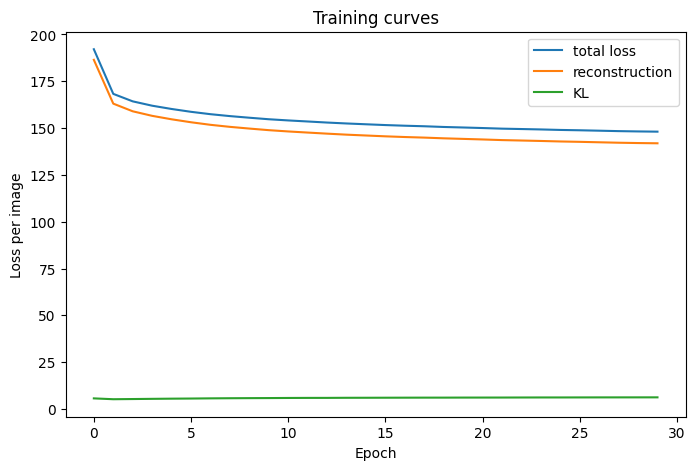

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="total loss")
plt.plot(history["reconstruction"], label="reconstruction")
plt.plot(history["kl"], label="KL")
plt.xlabel("Epoch")
plt.ylabel("Loss per image")
plt.title("Training curves")
plt.legend()
plt.show()


## 6. Generate New Digits from the Prior

A key difference between an autoencoder and a VAE is that the VAE defines a latent prior.

We can sample:

$$
z \sim \mathcal{N}(0, I)
$$

and decode the samples into images. This tests whether the decoder has learned a meaningful generative model.


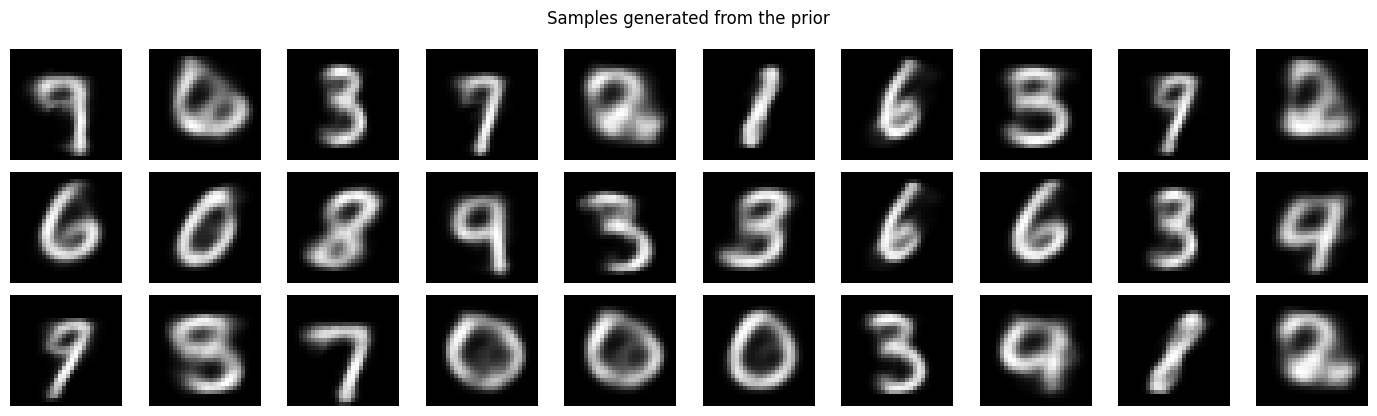

In [9]:
def sample_from_prior(model, n_images=20):
    model.eval()

    with torch.no_grad():
        z = torch.randn(n_images, model.latent_dim).to(device)
        samples = model.decode(z).cpu()

    n_cols = 10
    n_rows = int(np.ceil(n_images / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.4 * n_cols, 1.4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i in range(len(axes)):
        axes[i].axis("off")
        if i < n_images:
            axes[i].imshow(samples[i].squeeze(), cmap="gray")

    plt.suptitle("Samples generated from the prior")
    plt.tight_layout()
    plt.show()

sample_from_prior(model, n_images=30)


## 7. Decode a Grid in the Latent Space

When the latent space is two-dimensional, we can visualize what each region of the latent plane represents.

Each point in the grid is decoded into an image. Smooth transitions indicate that the model has learned a continuous representation.


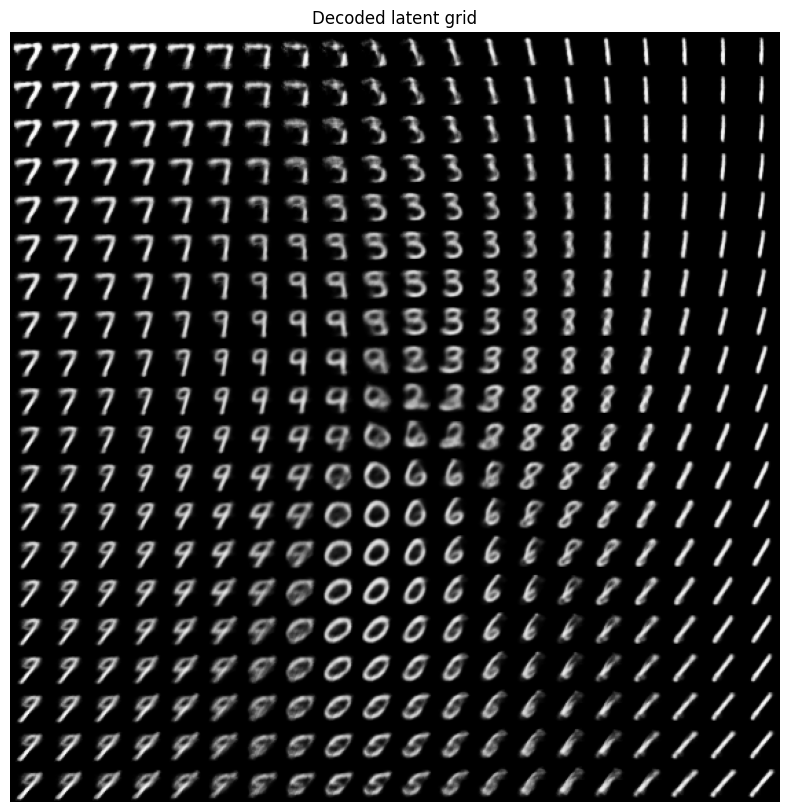

In [10]:
def plot_latent_grid(model, grid_size=20, value_range=(-3, 3)):
    if model.latent_dim != 2:
        print("This visualization requires latent_dim = 2.")
        return

    model.eval()

    x_values = np.linspace(value_range[0], value_range[1], grid_size)
    y_values = np.linspace(value_range[0], value_range[1], grid_size)

    canvas = np.zeros((28 * grid_size, 28 * grid_size))

    with torch.no_grad():
        for i, y in enumerate(y_values):
            for j, x in enumerate(x_values):
                z = torch.tensor([[x, y]], dtype=torch.float32).to(device)
                digit = model.decode(z).cpu().squeeze().numpy()

                row = i * 28
                col = j * 28
                canvas[row:row + 28, col:col + 28] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(canvas, cmap="gray")
    plt.axis("off")
    plt.title("Decoded latent grid")
    plt.show()

plot_latent_grid(model, grid_size=20, value_range=(-3, 3))


## 8. Interpolation Between Two Images

A good latent space should be continuous. To test this, we encode two images, linearly interpolate between their latent means, and decode the intermediate points.

If the VAE has learned a meaningful representation, the generated images should change gradually.


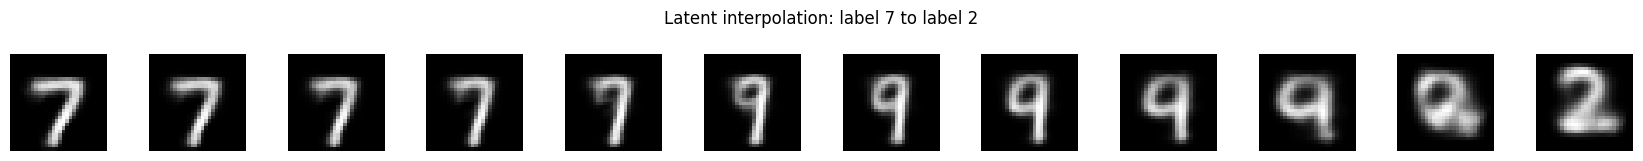

In [11]:
def interpolate_between_images(model, data_loader, idx_a=0, idx_b=1, n_steps=12):
    model.eval()

    data, labels = next(iter(data_loader))
    x_a = data[idx_a:idx_a + 1].to(device)
    x_b = data[idx_b:idx_b + 1].to(device)

    with torch.no_grad():
        mu_a, _ = model.encode(x_a)
        mu_b, _ = model.encode(x_b)

        alphas = torch.linspace(0, 1, n_steps).to(device)
        z = torch.stack([(1 - a) * mu_a.squeeze(0) + a * mu_b.squeeze(0) for a in alphas])

        decoded = model.decode(z).cpu()

    fig, axes = plt.subplots(1, n_steps, figsize=(1.4 * n_steps, 1.6))

    for i in range(n_steps):
        axes[i].imshow(decoded[i].squeeze(), cmap="gray")
        axes[i].axis("off")

    plt.suptitle(f"Latent interpolation: label {labels[idx_a].item()} to label {labels[idx_b].item()}")
    plt.tight_layout()
    plt.show()

interpolate_between_images(model, test_loader, idx_a=0, idx_b=1, n_steps=12)


## 9. Effect of the KL Weight

The parameter $\beta$ controls the strength of the KL regularization:

$$
\mathcal{L}_\beta(x)
=
\mathrm{BCE}(x, \hat{x})
+
\beta
\mathrm{KL}
\left(
q_\phi(z \mid x) \| p(z)
\right)
$$

This is often called a $\beta$-VAE.

Interpretation:
- small $\beta$: better reconstructions, weaker latent regularization
- large $\beta$: smoother latent space, but potentially blurrier reconstructions

Try changing `BETA` in the training cell and retrain the model. Then compare reconstructions, samples, and the latent grid.


## 10. Questions for Students

1. Why does the VAE use a distribution $q_\phi(z \mid x)$ instead of a deterministic vector $z$?
2. What is the role of the KL divergence term?
3. Why can the latent space look like a blob even if the model works correctly?
4. What changes when `LATENT_DIM = 20` instead of `LATENT_DIM = 2`?
5. How does increasing $\beta$ affect reconstruction quality and latent organization?
6. Why are generated samples sometimes blurrier than real MNIST digits?
7. Which digits overlap the most in the latent space, and why might this happen?
